In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [76]:
df = pd.read_csv("../data/cleaned/paper_leaks_cleaned.csv")

In [77]:
df.head()

,incident_id,date,era,exam_name,conducting_body,body_type,area,leak_status,action_taken,note,arrests,convictions,aspirants_affected,linked_deaths,deaths_note,source_name,source_url,confidence,arrests_status,conviction_status,deaths_status,exam_category,medical_type,engineering_type,forest_type,year,quarter,state,region,organization_level,severity,affected_group,exam_level,conducting_body_category,exam_mode,decade,state_code,region_code,affected_category,leak_confirmed,repeat_exam
0,PL-0001,2004-04-11,UPA (2004-May2014),All India Pre-Medical Test (AIPMT/CBSE-PMT) 2004,CBSE,Central,All India,Confirmed,Exam cancelled + Arrests-FIR + Probe (CBI/SIT),Physics and chemistry papers leaked in New Del...,2.0,NaN,NaN,NaN,NaN,The Tribune,https://www.tribuneindia.com/2004/20040412/mai...,High,Arrests Made,Not Reported,Not Reported,Medical,State PMT,Not Engineering,Not Forest,2004,Q2,Multiple States,Multiple Regions,National,Unknown,Unknown,UG,CBSE Board,Unknown,2000s,IN,NAT,Unknown,Confirmed,No
1,PL-0002,2006-06-01,UPA (2004-May2014),Himachal Pradesh Combined Pre-Medical Test (HP...,Himachal Pradesh University,State,Himachal Pradesh,Confirmed,Retest + Arrests-FIR,HP-CPMT medical entrance paper leaked via a to...,NaN,NaN,NaN,NaN,NaN,The Tribune,https://www.tribuneindia.com/2006/20060831/him...,Medium,Not Reported,Not Reported,Not Reported,Medical,State Medical Entrance,Not Engineering,Not Forest,2006,Q2,Himachal Pradesh,North,State,Unknown,Unknown,UG,University,Unknown,2000s,HP,N,Unknown,Suspected,No
2,PL-0003,2008-01-01,UPA (2004-May2014),Vyapam Patwari Recruitment Examination 2008,Madhya Pradesh Professional Examination Board ...,State,Madhya Pradesh,Confirmed,Arrests-FIR + Probe (CBI/SIT),Accused produced forged educational certificat...,NaN,10.0,NaN,NaN,NaN,The420.in,https://the420.in/vyapam-scam-cbi-court-patwar...,High,Not Reported,Convictions Reported,Not Reported,Government Recruitment,Not Medical,Not Engineering,Not Forest,2008,Q1,Madhya Pradesh,Central,State,Unknown,Unknown,Recruitment,State Recruitment Board,Unknown,2000s,MP,C,Unknown,Confirmed,No
3,PL-0004,2009-07-08,UPA (2004-May2014),MP Pre-Medical Test (PMT) 2009,Vyapam (MPPEB),State,Madhya Pradesh,Confirmed,Arrests-FIR + Probe (CBI/SIT),Paid solvers/impersonators sat the exam in pla...,NaN,NaN,114.0,NaN,NaN,The Free Press Journal,https://www.freepressjournal.in/education/indo...,High,Not Reported,Not Reported,Not Reported,Medical,State PMT,Not Engineering,Not Forest,2009,Q3,Madhya Pradesh,Central,State,Low,<10K,UG,State Recruitment Board,Unknown,2000s,MP,C,Low,Confirmed,No
4,PL-0005,2010-06-06,UPA (2004-May2014),RRB Mumbai 2010 recruitment exam (Assistant Lo...,"Railway Recruitment Board (RRB), Mumbai",Central,All India,Confirmed,Arrests-FIR + Probe (CBI/SIT),CBI registered a case on 15 June 2010 over the...,15.0,10.0,NaN,NaN,NaN,The Week,https://www.theweek.in/wire-updates/national/2...,High,Arrests Made,Convictions Reported,Not Reported,Police,Not Medical,Not Engineering,Not Forest,2010,Q2,Multiple States,Multiple Regions,National,Unknown,Unknown,Recruitment,Railway,Unknown,2010s,IN,NAT,Unknown,Confirmed,No


In [15]:
# # Exploratory Data Analysis (EDA)

# ## 1. Dataset Overview

# The objective of this section is to understand the overall structure of the dataset before performing detailed analysis.
#  This includes examining the number of rows, columns, data types, and missing values.

In [17]:
print("=" * 50)
print("PAPER LEAK ANALYSIS DATASET OVERVIEW")
print("=" * 50)

print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

PAPER LEAK ANALYSIS DATASET OVERVIEW
Total Rows    : 110
Total Columns : 41


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               110 non-null    object 
 1   date                      110 non-null    object 
 2   era                       110 non-null    object 
 3   exam_name                 110 non-null    object 
 4   conducting_body           110 non-null    object 
 5   body_type                 110 non-null    object 
 6   area                      110 non-null    object 
 7   leak_status               110 non-null    object 
 8   action_taken              110 non-null    object 
 9   note                      110 non-null    object 
 10  arrests                   63 non-null     float64
 11  convictions               10 non-null     float64
 12  aspirants_affected        44 non-null     float64
 13  linked_deaths             4 non-null      float64
 14  deaths_not

In [78]:
df = pd.read_csv("../data/cleaned/paper_leaks_cleaned.csv")

In [79]:
df["date"] = pd.to_datetime(df["date"])

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   incident_id               110 non-null    object        
 1   date                      110 non-null    datetime64[ns]
 2   era                       110 non-null    object        
 3   exam_name                 110 non-null    object        
 4   conducting_body           110 non-null    object        
 5   body_type                 110 non-null    object        
 6   area                      110 non-null    object        
 7   leak_status               110 non-null    object        
 8   action_taken              110 non-null    object        
 9   note                      110 non-null    object        
 10  arrests                   63 non-null     float64       
 11  convictions               10 non-null     float64       
 12  aspirants_affected    

In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
incident_id,110,110,PL-0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,110,NaN,NaN,NaN,2019-08-23 20:43:38.181818112,2004-04-11 00:00:00,2015-11-26 00:00:00,2021-09-29 12:00:00,2023-05-21 12:00:00,2026-07-19 00:00:00,NaN
era,110,2,NDA (May2014-now),86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exam_name,110,109,Forest Guard recruitment exam,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conducting_body,110,70,Vyapam (MPPEB),6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_type,110,2,State,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,110,56,All India,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
leak_status,110,4,Confirmed,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
action_taken,110,42,Arrests-FIR + Probe (CBI/SIT),19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
note,110,110,Physics and chemistry papers leaked in New Del...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

linked_deaths               106
deaths_note                 106
convictions                 100
aspirants_affected           66
arrests                      47
state_code                   43
year                          0
quarter                       0
state                         0
region                        0
organization_level            0
severity                      0
affected_group                0
incident_id                   0
engineering_type              0
exam_level                    0
conducting_body_category      0
exam_mode                     0
decade                        0
region_code                   0
affected_category             0
leak_confirmed                0
forest_type                   0
deaths_status                 0
medical_type                  0
action_taken                  0
era                           0
exam_name                     0
conducting_body               0
body_type                     0
area                          0
leak_sta

In [81]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

linked_deaths               96.363636
deaths_note                 96.363636
convictions                 90.909091
aspirants_affected          60.000000
arrests                     42.727273
state_code                  39.090909
year                         0.000000
quarter                      0.000000
state                        0.000000
region                       0.000000
organization_level           0.000000
severity                     0.000000
affected_group               0.000000
incident_id                  0.000000
engineering_type             0.000000
exam_level                   0.000000
conducting_body_category     0.000000
exam_mode                    0.000000
decade                       0.000000
region_code                  0.000000
affected_category            0.000000
leak_confirmed               0.000000
forest_type                  0.000000
deaths_status                0.000000
medical_type                 0.000000
action_taken                 0.000000
era         

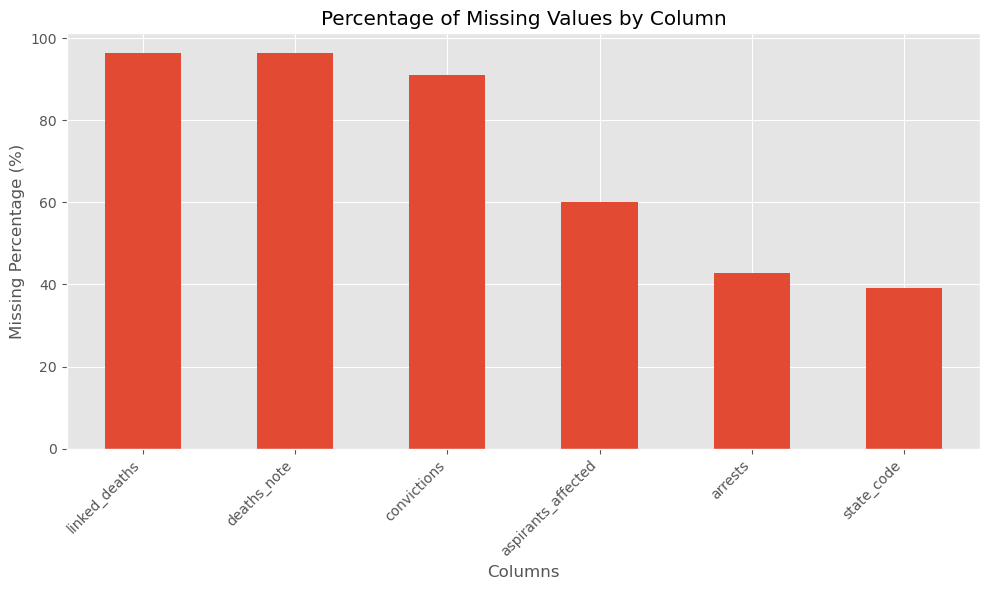

In [82]:
import matplotlib.pyplot as plt
# Step 2: Create the Missing Values Bar Chart
# Calculate missing percentages
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

# Keep only columns with missing values
missing_percentage = missing_percentage[missing_percentage > 0]

# Plot
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind="bar")

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
## Observation

# - `linked_deaths` and `deaths_note` have the highest percentage of missing values (96.36%), 
# indicating that information about deaths is available for only a few incidents.


# - `convictions` is missing in 90.91% of the records, suggesting that conviction outcomes are often unavailable or not reported.
# - `aspirants_affected` is missing for 60% of incidents, meaning the number of affected candidates is unknown in many cases.
# - `arrests` is missing in 42.73% of the records, reflecting incomplete reporting of legal actions.
# - Most engineered features and categorical columns have no missing values, showing that the data cleaning and feature engineering process successfully prepared the dataset for analysis.

In [83]:
## 3. Paper Leak Trends Over Time

# This section analyzes how paper leak incidents have changed over the years to identify long-term trends

yearly_leaks = df["year"].value_counts().sort_index()

yearly_leaks

year
2004     1
2006     1
2008     1
2009     1
2010     1
2011     5
2012     8
2013     5
2014     2
2015     3
2016     3
2017     5
2018     5
2019     2
2020     4
2021    14
2022    15
2023    11
2024    12
2025     5
2026     6
Name: count, dtype: int64

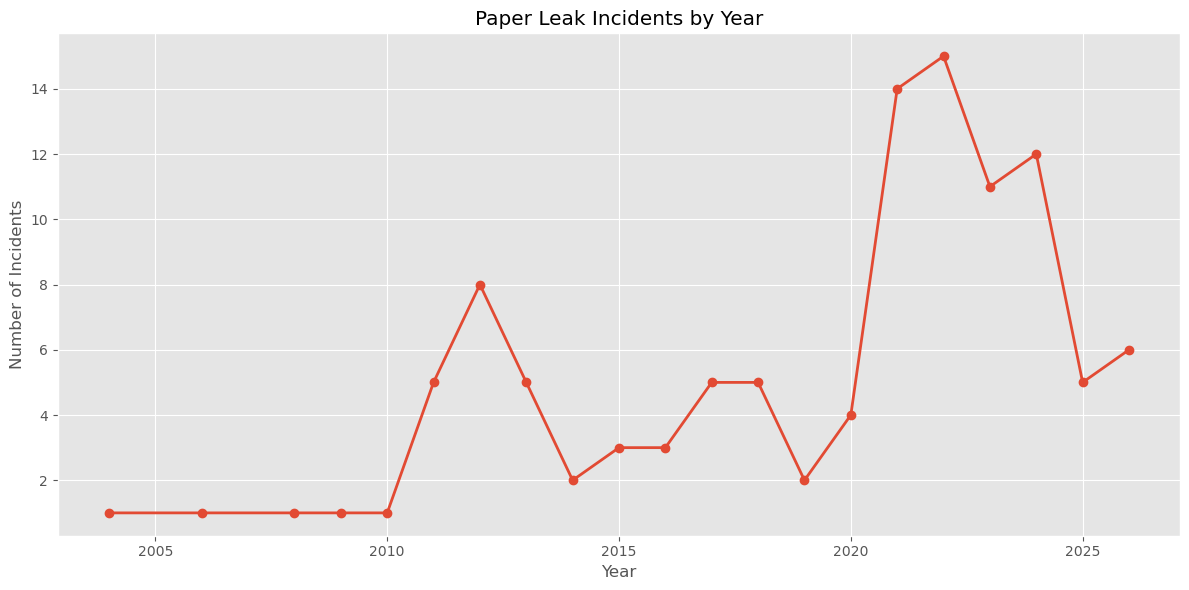

In [84]:
plt.figure(figsize=(12,6))

yearly_leaks.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Paper Leak Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")

plt.grid(True)

plt.tight_layout()
plt.show()



### Observation

# - The chart shows the number of reported paper leak incidents each year.
# - The distribution helps identify years with unusually high or low numbers of incidents.
# - This trend can indicate whether paper leaks have become more frequent over time.

In [85]:
# ## 4. State-wise Analysis

# This section identifies the states that have experienced the highest number of reported paper leak incidents.
state_counts = df["state"].value_counts()

state_counts.head(10)

state
Multiple States    16
Madhya Pradesh     13
Uttar Pradesh      12
Rajasthan          11
Bihar               6
Uttarakhand         6
Maharashtra         5
Gujarat             5
Haryana             5
Punjab              4
Name: count, dtype: int64

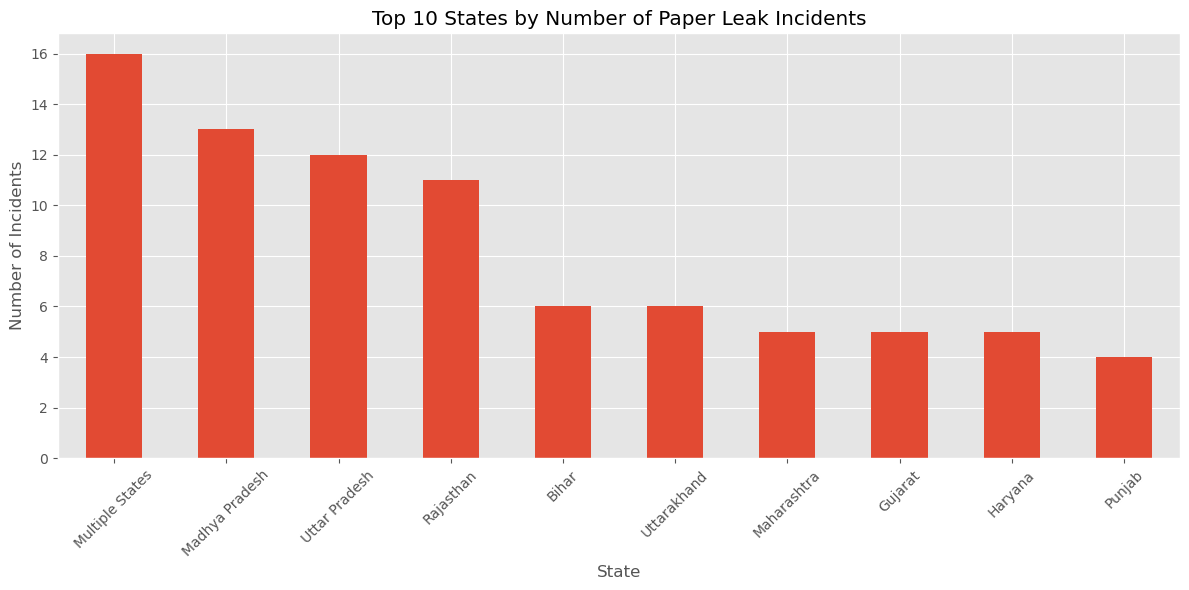

In [86]:
plt.figure(figsize=(12,6))

state_counts.head(10).plot(kind="bar")

plt.title("Top 10 States by Number of Paper Leak Incidents")
plt.xlabel("State")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [87]:
# ## 5. Exam Category Analysis

# This section examines which categories of examinations are most frequently associated with paper leak incidents.

exam_category = df["exam_category"].value_counts()

exam_category

exam_category
Medical                   22
Government Recruitment    22
Police                    11
Teacher                   11
Banking                   11
Engineering                8
School Board               7
Civil Services             6
Forest                     5
Railway                    2
Food Inspector             1
Agriculture                1
Judiciary                  1
Defence                    1
Higher Education           1
Name: count, dtype: int64

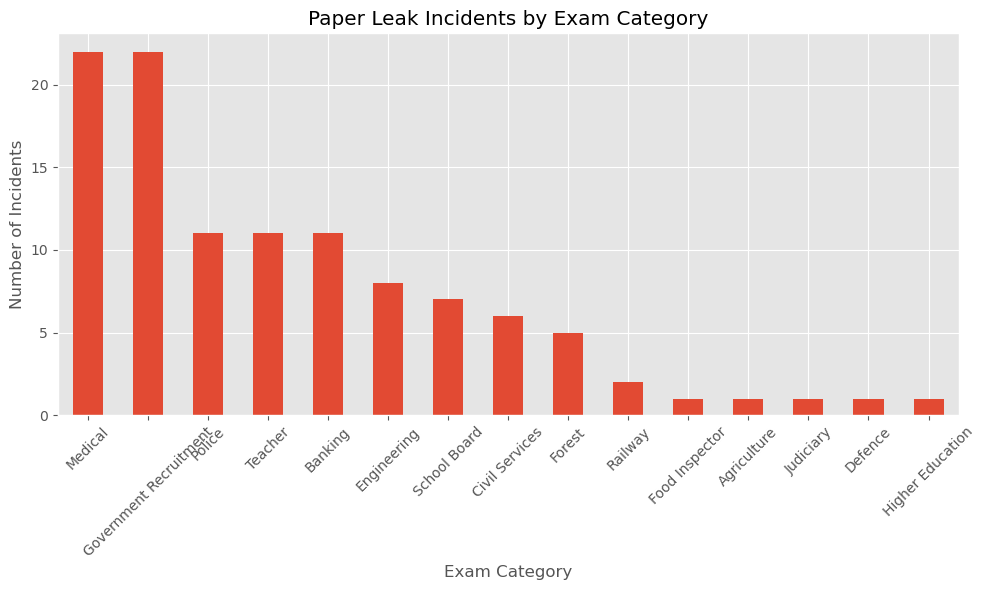

In [88]:
plt.figure(figsize=(10,6))

exam_category.plot(kind="bar")

plt.title("Paper Leak Incidents by Exam Category")
plt.xlabel("Exam Category")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



# ### Observation

# - The chart compares paper leak incidents across different exam categories.
# - It helps identify which sectors are most vulnerable to examination malpractice.

In [89]:
# ## 6. Conducting Body Analysis

# This section identifies the examination conducting bodies that have experienced the highest number of reported paper leak incidents.
conducting_body_counts = df["conducting_body"].value_counts()

conducting_body_counts.head(10)

conducting_body
CBSE                                                             9
Vyapam (MPPEB)                                                   6
NTA                                                              4
Rajasthan Staff Selection Board (RSMSSB)                         4
Uttarakhand Subordinate Service Selection Commission (UKSSSC)    4
Bihar Public Service Commission (BPSC)                           3
Jharkhand Staff Selection Commission (JSSC)                      3
Rajasthan Public Service Commission (RPSC)                       3
Uttarakhand Public Service Commission (UKPSC)                    2
Haryana Staff Selection Commission (HSSC)                        2
Name: count, dtype: int64

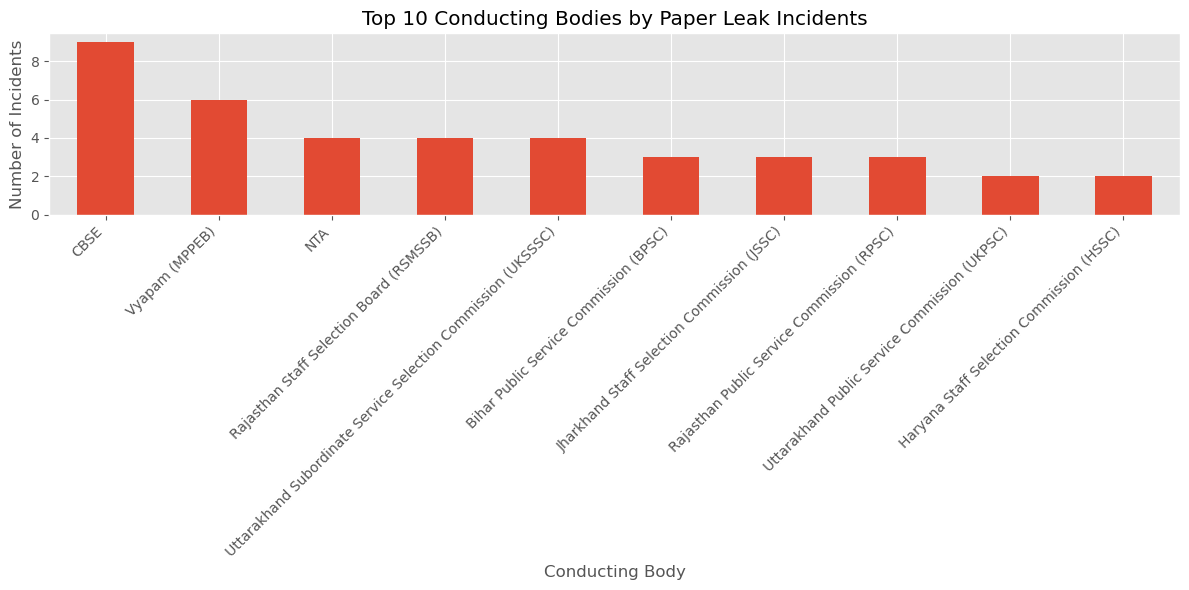

In [90]:
plt.figure(figsize=(12,6))

conducting_body_counts.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Conducting Bodies by Paper Leak Incidents")
plt.xlabel("Conducting Body")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [50]:
df = pd.read_csv("../data/cleaned/paper_leaks_cleaned.csv")

In [92]:
# ## 7. Organization Level Analysis

# This section compares paper leak incidents between State-level and National-level examination organizations. 
# The analysis helps determine whether paper leak incidents are more common in examinations conducted at the state or national level.
organization_counts = df["organization_level"].value_counts()

organization_counts

organization_level
State       78
National    32
Name: count, dtype: int64

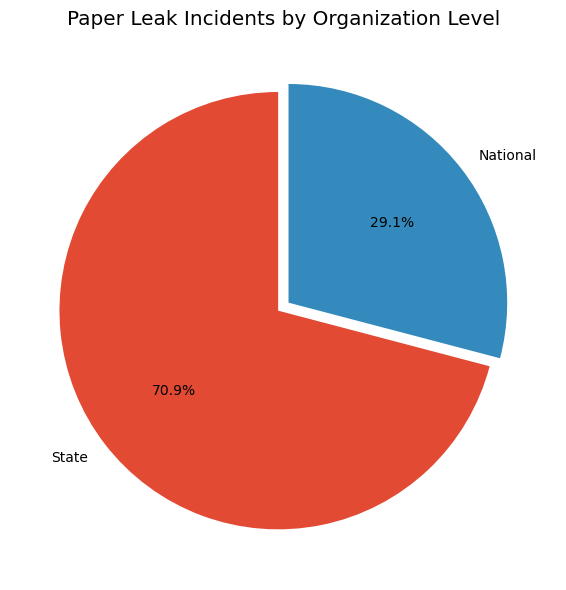

In [93]:
plt.figure(figsize=(7,6))

organization_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03, 0.03]
)

plt.title("Paper Leak Incidents by Organization Level")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [94]:
# ## 8. Top 10 Paper Leak Incidents by Aspirants Affected

# This section identifies the paper leak incidents that affected the largest number of aspirants.
#  Only records with available aspirant data are considered for this analysis.


affected = df.dropna(subset=["aspirants_affected"])

top10 = affected.sort_values(
    by="aspirants_affected",
    ascending=False
).head(10)

top10[["exam_name", "aspirants_affected"]]

,exam_name,aspirants_affected
89,UP Police Constable Recruitment Exam 2024,4800000.0
92,NEET-UG 2024,2300000.0
107,NEET-UG 2026,2270000.0
57,Uttar Pradesh Teacher Eligibility Test (UPTET)...,1999000.0
56,Patwari (village revenue officer) recruitment ...,1562000.0
80,MP Patwari Recruitment Exam 2023 (Group-2 Sub-...,974000.0
77,GPSSB Junior Clerk recruitment exam,953000.0
93,UGC-NET June 2024,900000.0
85,Talathi (village accountant) recruitment exam,865000.0
48,HSSC Gram Sachiv (Panchayat Secretary) exam,800000.0


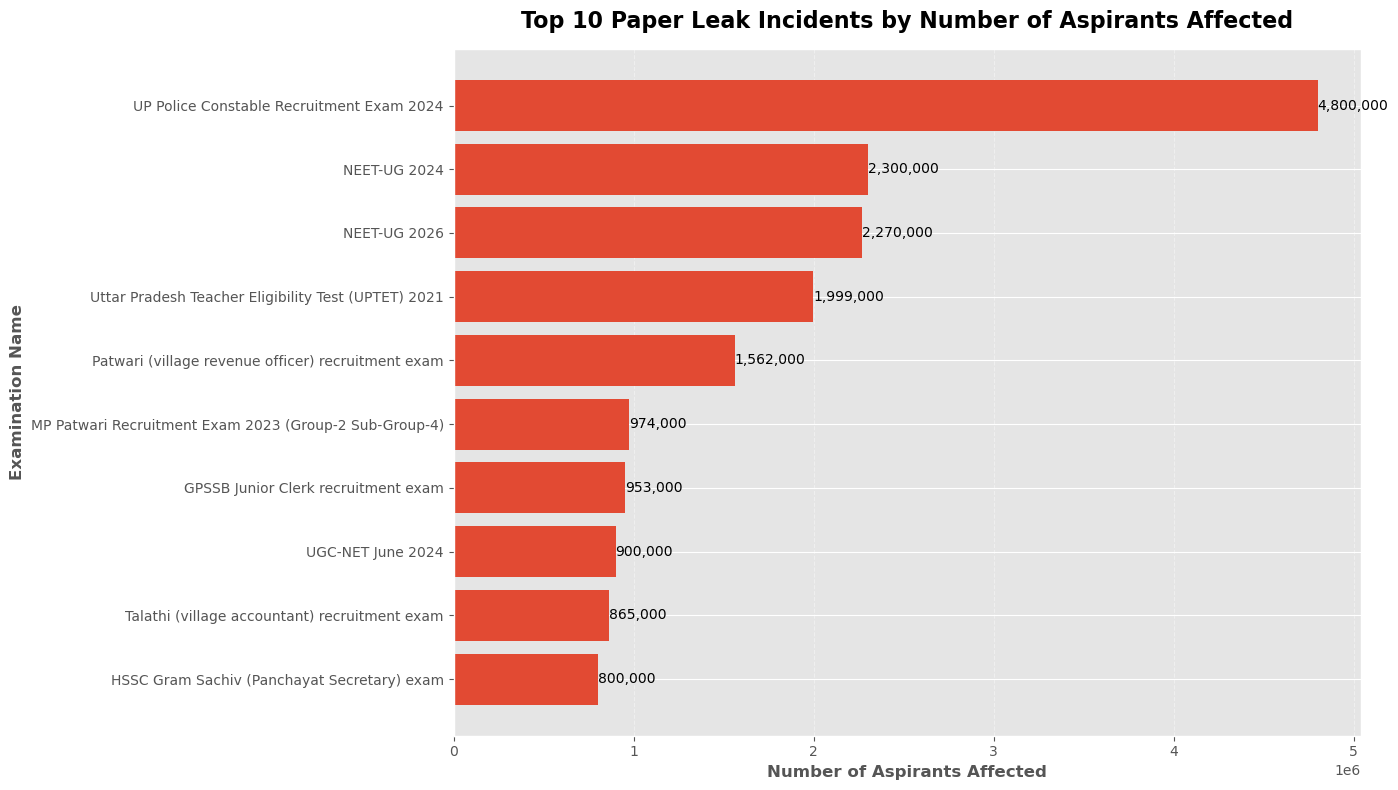

In [95]:
affected = df.dropna(subset=["aspirants_affected"])

top10 = (
    affected.sort_values(
        by="aspirants_affected",
        ascending=False
    )
    .head(10)
    .sort_values(by="aspirants_affected")
)

plt.figure(figsize=(14,8))

bars = plt.barh(
    top10["exam_name"],
    top10["aspirants_affected"]
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Paper Leak Incidents by Number of Aspirants Affected",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Aspirants Affected",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Examination Name",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [96]:
# ## 9. Arrest Analysis

# This section examines the number of arrests made in paper leak incidents. It helps understand the legal response to examination malpractice 
# and identifies incidents that resulted in the highest number of arrests.


arrest_data = df.dropna(subset=["arrests"])

top10_arrests = (
    arrest_data.sort_values(
        by="arrests",
        ascending=False
    )
    .head(10)
    .sort_values(by="arrests")
)

top10_arrests[["exam_name", "arrests"]]

,exam_name,arrests
54,REET 2021 (Rajasthan Eligibility Exam for Teac...,38.0
74,Senior Teacher Grade II (2nd Grade Teacher) Ge...,44.0
89,UP Police Constable Recruitment Exam 2024,54.0
53,Sub-Inspector (SI) recruitment exam 2021,54.0
65,SSC (Class 10) board examination,70.0
64,Himachal Pradesh Police Constable Recruitment ...,88.0
86,Bihar Police Constable Recruitment Written Exam,148.0
106,Jharkhand Excise Constable Competitive Exam (J...,164.0
51,HSSC Police Constable (Male) recruitment exam,167.0
90,BPSC TRE 3.0 School Teacher Recruitment Exam,266.0


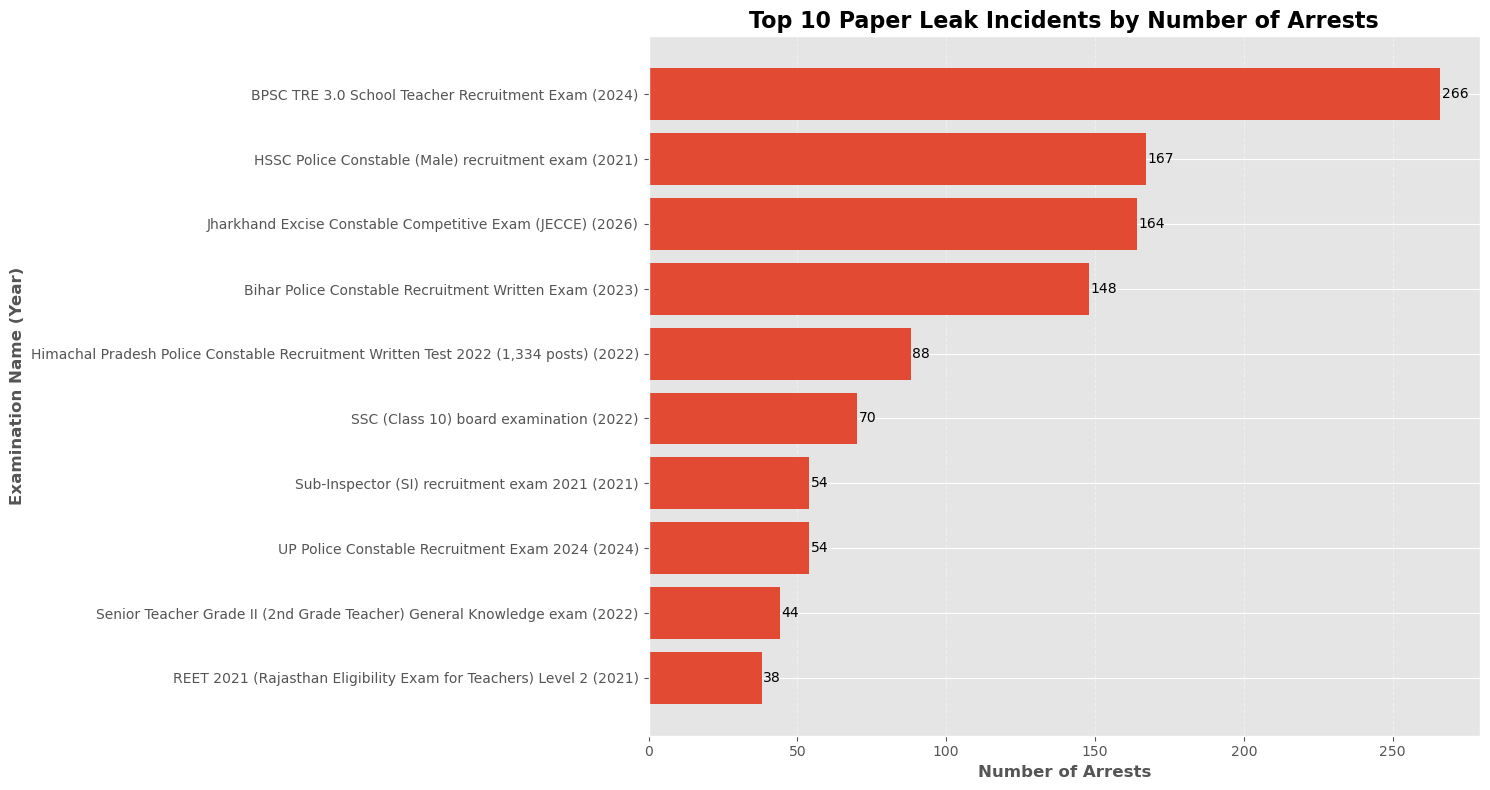

In [97]:
arrest_data = df.dropna(subset=["arrests"])

top10_arrests = (
    arrest_data.sort_values(
        by="arrests",
        ascending=False
    )
    .head(10)
    .sort_values(by="arrests")
)

plt.figure(figsize=(15,8))

labels = top10_arrests.apply(
    lambda x: f"{x['exam_name']} ({int(x['year'])})",
    axis=1
)

bars = plt.barh(
    labels,
    top10_arrests["arrests"]
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Paper Leak Incidents by Number of Arrests",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Arrests",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Examination Name (Year)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [98]:
## 10. Relationship Between Aspirants Affected and Arrests

# This section explores whether paper leak incidents that affected a larger number of aspirants also resulted in a higher number of arrests. 
# Understanding this relationship helps assess whether the scale of an incident influences the legal response.
scatter_data = df.dropna(subset=["aspirants_affected", "arrests"])

scatter_data = scatter_data[
    (scatter_data["aspirants_affected"] > 0) &
    (scatter_data["arrests"] > 0)
]

scatter_data.head()

,incident_id,date,era,exam_name,conducting_body,body_type,area,leak_status,action_taken,note,arrests,convictions,aspirants_affected,linked_deaths,deaths_note,source_name,source_url,confidence,arrests_status,conviction_status,deaths_status,exam_category,medical_type,engineering_type,forest_type,year,quarter,state,region,organization_level,severity,affected_group,exam_level,conducting_body_category,exam_mode,decade,state_code,region_code,affected_category,leak_confirmed,repeat_exam
7,PL-0008,2011-05-01,UPA (2004-May2014),AIEEE (All India Engineering Entrance Examinat...,CBSE,Central,Uttar Pradesh (Kanpur/Lucknow),Confirmed,Retest + Arrests-FIR,Paper found being sold in UP (allegedly for ~R...,1.0,NaN,32000.0,NaN,NaN,icbse.com,https://www.icbse.com/news/aieee-2011-question...,High,Arrests Made,Not Reported,Not Reported,Engineering,Not Medical,Engineering Entrance,Not Forest,2011,Q2,Uttar Pradesh,Unknown,National,Medium,10K-50K,Recruitment,CBSE Board,Unknown,2010s,NaN,UNK,High,Confirmed,No
8,PL-0009,2011-06-19,UPA (2004-May2014),Chhattisgarh Pre-Medical Test (CG-PMT) 2011,Chhattisgarh Professional Examination Board (C...,State,Chhattisgarh,Confirmed,Exam cancelled + Arrests-FIR,CG-PMT scrapped after a crime-branch raid at a...,12.0,NaN,20000.0,NaN,NaN,India TV News,https://www.indiatvnews.com/news/india/chhatis...,High,Arrests Made,Not Reported,Not Reported,Medical,State PMT,Not Engineering,Not Forest,2011,Q2,Chhattisgarh,Central,State,Medium,10K-50K,UG,State Recruitment Board,Unknown,2010s,CG,C,Moderate,Confirmed,No
25,PL-0026,2015-03-29,NDA (May2014-now),UPPCS Preliminary Examination 2015,Uttar Pradesh Public Service Commission (UPPSC),State,Uttar Pradesh (Lucknow),Confirmed,Exam cancelled+Arrests-FIR,Question paper was photographed about an hour ...,3.0,NaN,450000.0,NaN,NaN,The Tribune,https://www.tribuneindia.com/news/archive/nati...,High,Arrests Made,Not Reported,Not Reported,Civil Services,Not Medical,Not Engineering,Not Forest,2015,Q1,Uttar Pradesh,Unknown,State,High,>50K,Other,State PSC,Unknown,2010s,NaN,UNK,Very High,Confirmed,No
27,PL-0028,2015-11-14,NDA (May2014-now),HTET Level-3 (Haryana Teacher Eligibility Test),Haryana Board of School Education (HBSE),State,Haryana (Jind),Confirmed,Exam cancelled + Arrests-FIR,Board cancelled the Level-3 exam the same day ...,5.0,NaN,137000.0,NaN,NaN,The Tribune,https://www.tribuneindia.com/news/archive/hary...,High,Arrests Made,Not Reported,Not Reported,Teacher,Not Medical,Not Engineering,Not Forest,2015,Q4,Haryana,Unknown,State,High,>50K,Recruitment,Education Department,Unknown,2010s,NaN,UNK,Very High,Confirmed,No
40,PL-0041,2018-09-02,NDA (May2014-now),UPSSSC Tubewell Operator (Nalkoop Chalak) Recr...,Uttar Pradesh Subordinate Services Selection C...,State,Uttar Pradesh (Meerut),Confirmed,Exam cancelled+Arrests-FIR,The Hindi question paper leaked and was sold f...,11.0,NaN,250000.0,NaN,NaN,Ground Report,https://www.groundreport.in/education/how-many...,Medium,Arrests Made,Not Reported,Not Reported,Government Recruitment,Not Medical,Not Engineering,Not Forest,2018,Q3,Uttar Pradesh,Unknown,National,High,>50K,Recruitment,SSC,Unknown,2010s,NaN,UNK,Very High,Suspected,No


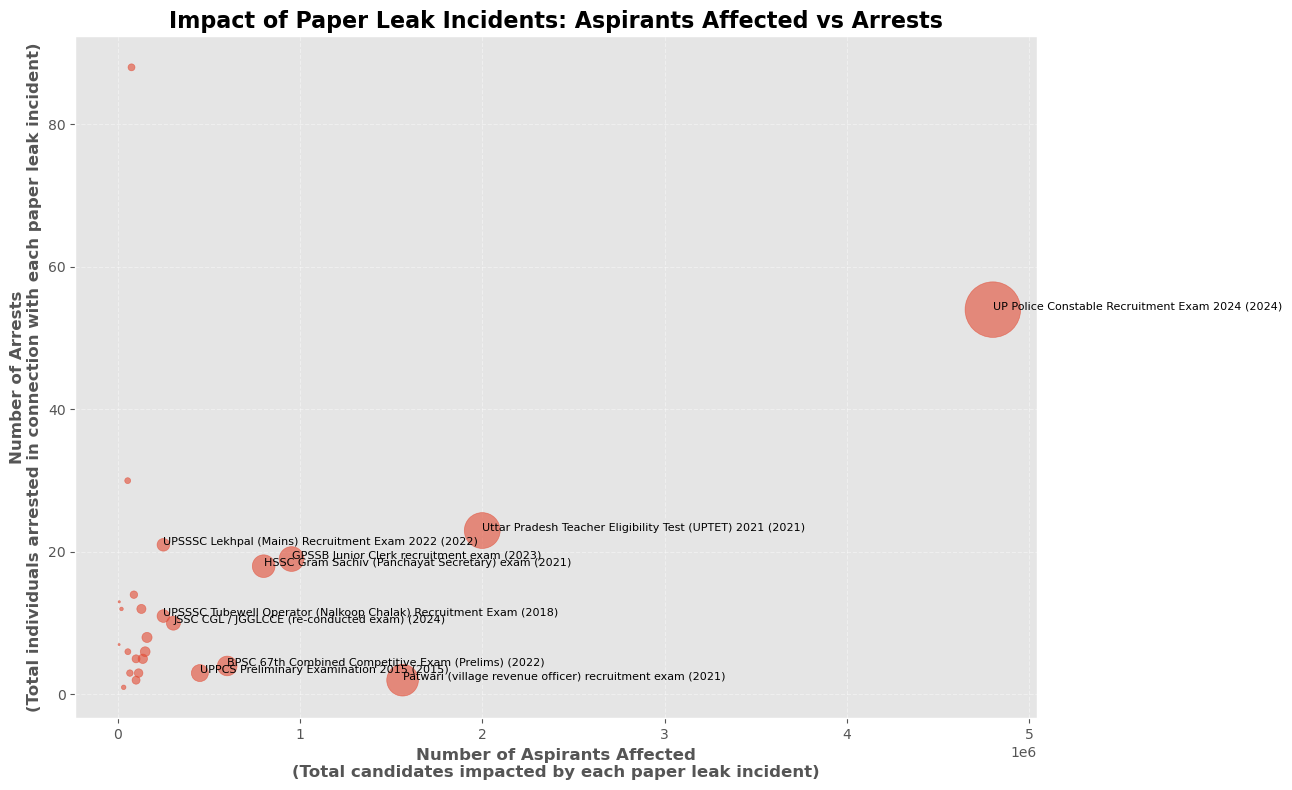

In [99]:
scatter_data = df.dropna(subset=["aspirants_affected", "arrests"])

scatter_data = scatter_data[
    (scatter_data["aspirants_affected"] > 0) &
    (scatter_data["arrests"] > 0)
]

plt.figure(figsize=(13,8))

sizes = scatter_data["aspirants_affected"] / 3000

plt.scatter(
    scatter_data["aspirants_affected"],
    scatter_data["arrests"],
    s=sizes,
    alpha=0.6
)

# Label only the most impactful incidents
top = scatter_data.nlargest(10, "aspirants_affected")

for _, row in top.iterrows():
    plt.text(
        row["aspirants_affected"],
        row["arrests"],
        f"{row['exam_name']} ({int(row['year'])})",
        fontsize=8
    )

plt.title(
    "Impact of Paper Leak Incidents: Aspirants Affected vs Arrests",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Aspirants Affected\n(Total candidates impacted by each paper leak incident)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Arrests\n(Total individuals arrested in connection with each paper leak incident)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [100]:
# ## 11. Year-wise Distribution of Exam Categories

# This section analyzes how paper leak incidents across different examination categories have changed over the years.
# The heatmap helps identify periods during which specific categories experienced a higher concentration of paper leak incidents.
year_category = pd.crosstab(
    df["year"],
    df["exam_category"]
)

year_category

exam_category,Agriculture,Banking,Civil Services,Defence,Engineering,Food Inspector,Forest,Government Recruitment,Higher Education,Judiciary,Medical,Police,Railway,School Board,Teacher
year,,,,,,,,,,,,,,,
2004,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2006,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2008,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2009,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2010,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2011,0,0,0,0,1,0,0,0,0,0,1,0,0,1,2
2012,0,2,0,0,0,1,0,0,0,0,4,0,0,1,0
2013,1,1,1,0,0,0,0,1,0,0,1,0,0,0,0
2014,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0


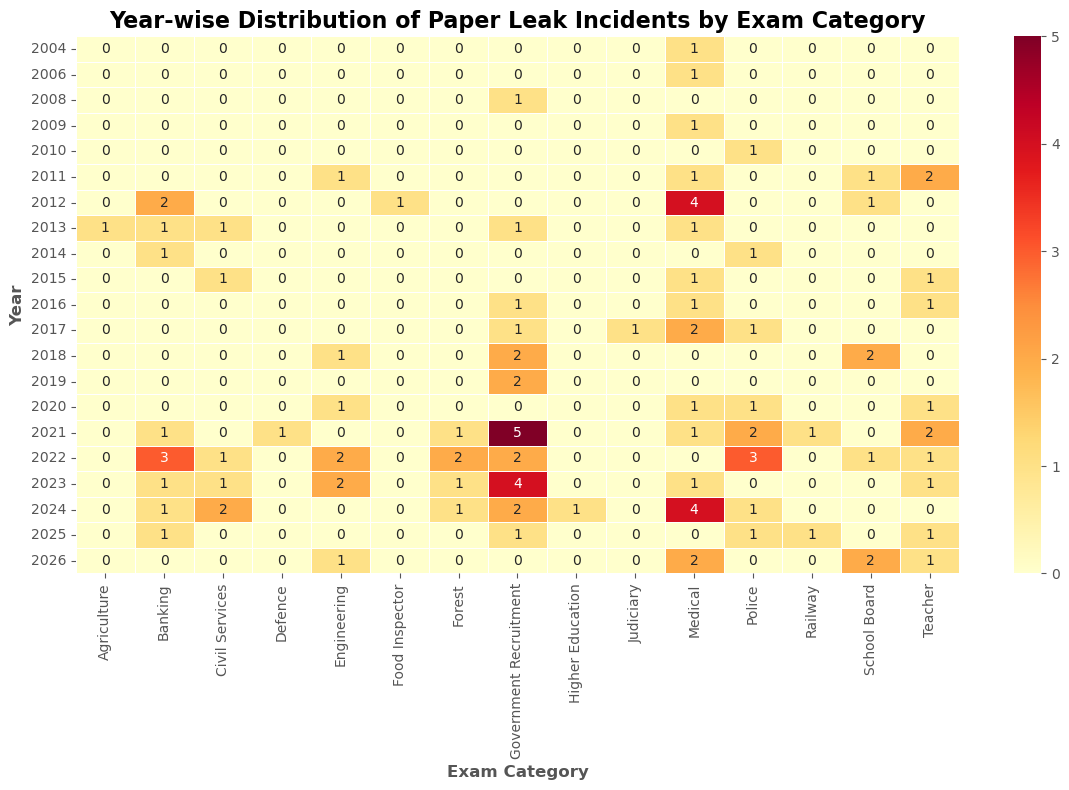

In [101]:
plt.figure(figsize=(12,8))

sns.heatmap(
    year_category,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Year-wise Distribution of Paper Leak Incidents by Exam Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Exam Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Year",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()